In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('climate_data_aggregated_by_month_and_district.csv')

In [3]:
df

,feature,month,tp,e,ro,t2m,stl1,d2m,stl2,swvl1,swvl2,cvh,cvl,slt
0,A & N Islands_Nicobars,1,0.155895,-0.145155,0.000000,299.957974,301.395849,296.205143,301.395933,7.828219e-07,9.263556e-07,0.000000,0.000000,0.00
1,A & N Islands_Nicobars,2,0.073241,-0.127951,0.000000,300.347773,301.663718,296.253400,301.655300,-1.457989e-06,-8.020846e-08,0.000000,0.000000,0.00
2,A & N Islands_Nicobars,3,0.107033,-0.118626,0.000000,300.728570,302.288358,296.591939,302.276559,-1.509114e-06,-8.345849e-07,0.000000,0.000000,0.00
3,A & N Islands_Nicobars,4,0.134209,-0.101045,0.000000,300.984711,302.984163,297.179667,302.976795,-2.279712e-07,2.165511e-06,0.000000,0.000000,0.00
4,A & N Islands_Nicobars,5,0.265185,-0.136944,0.000000,300.947370,302.708544,297.735900,302.719828,3.265345e-07,-1.801931e-06,0.000000,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9271,West Bengal_Purulia,8,0.286655,-0.108605,0.091595,301.316108,301.991658,298.498164,301.356652,4.016572e-01,4.017722e-01,0.317097,0.668795,2.25
9272,West Bengal_Purulia,9,0.232007,-0.106522,0.097131,301.040230,301.816350,298.070948,301.156227,3.893341e-01,3.896617e-01,0.317097,0.668795,2.25
9273,West Bengal_Purulia,10,0.092837,-0.102173,0.072248,299.260643,300.044396,294.979955,299.625393,3.149695e-01,3.254036e-01,0.317097,0.668795,2.25
9274,West Bengal_Purulia,11,0.008047,-0.069953,0.029248,295.191450,296.073610,289.408941,296.285416,2.077455e-01,2.354825e-01,0.317097,0.668795,2.25


In [4]:
# Pivot for t2m 
t2m_pivot = df.pivot(index='feature', columns='month', values='t2m')
t2m_pivot.columns = [f't2m_month_{int(col)}' for col in t2m_pivot.columns]

# Pivot for tp 
tp_pivot = df.pivot(index='feature', columns='month', values='tp')
tp_pivot.columns = [f'tp_month_{int(col)}' for col in tp_pivot.columns]

# Pivot for stl1
stl1_pivot = df.pivot(index='feature', columns='month', values='stl1')
stl1_pivot.columns = [f'stl1_month_{int(col)}' for col in stl1_pivot.columns]

# Pivot for stl2
stl2_pivot = df.pivot(index='feature', columns='month', values='stl2')
stl2_pivot.columns = [f'stl2_month_{int(col)}' for col in stl2_pivot.columns]

# Pivot for swvl1
swvl1_pivot = df.pivot(index='feature', columns='month', values='swvl1')
swvl1_pivot.columns = [f'swvl1_month_{int(col)}' for col in swvl1_pivot.columns]

# Pivot for swvl2
swvl2_pivot = df.pivot(index='feature', columns='month', values='swvl2')
swvl2_pivot.columns = [f'swvl2_month_{int(col)}' for col in swvl2_pivot.columns]

slt_pivot = df.pivot(index='feature', columns='month', values='slt')
slt_pivot.columns = [f'slt_stat_{int(col) - 1}' for col in slt_pivot.columns]

In [5]:
district_features = pd.concat([t2m_pivot, tp_pivot, stl1_pivot, stl2_pivot, swvl1_pivot, swvl1_pivot, slt_pivot['slt_stat_0']], axis=1)
district_features = district_features.reset_index()

In [6]:
district_features

,feature,t2m_month_1,t2m_month_2,t2m_month_3,t2m_month_4,t2m_month_5,t2m_month_6,t2m_month_7,t2m_month_8,t2m_month_9,...,swvl1_month_4,swvl1_month_5,swvl1_month_6,swvl1_month_7,swvl1_month_8,swvl1_month_9,swvl1_month_10,swvl1_month_11,swvl1_month_12,slt_stat_0
0,A & N Islands_Nicobars,299.957974,300.347773,300.728570,300.984711,300.947370,300.805850,300.558290,300.400164,300.164819,...,-2.279712e-07,3.265345e-07,-0.000002,0.000003,6.168714e-07,1.185924e-07,5.417028e-07,0.000001,9.283610e-07,0.000000
1,A & N Islands_North And Middle Andaman,299.105631,299.346751,300.204414,301.536886,301.261929,300.683987,300.384669,300.190077,299.968929,...,6.023112e-02,1.046961e-01,0.122108,0.124909,1.250767e-01,1.264313e-01,1.239917e-01,0.111742,9.341353e-02,0.964286
2,A & N Islands_South Andamans,299.677792,299.934294,300.572428,301.521265,301.220669,300.823124,300.556674,300.399425,300.138697,...,8.728921e-03,1.489253e-02,0.016613,0.016778,1.673569e-02,1.689070e-02,1.661643e-02,0.015243,1.301985e-02,0.176471
3,Andhra Pradesh_Alluri Sitharama Raju,294.412516,296.703720,299.569667,301.321929,302.577051,300.741897,298.874480,298.665552,298.794598,...,2.276777e-01,2.491967e-01,0.341821,0.403282,4.078528e-01,4.057680e-01,3.658321e-01,0.288379,2.244060e-01,3.056075
4,Andhra Pradesh_Anakapalli,295.514630,297.411993,300.050422,301.984877,303.374095,302.540390,301.023818,300.776810,300.619857,...,1.410821e-01,1.590225e-01,0.231697,0.294554,3.049603e-01,3.098835e-01,2.762079e-01,0.205844,1.568685e-01,2.606060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
768,West Bengal_Murshidabad,290.299071,294.231192,299.216041,302.600849,303.073109,303.258245,302.530363,302.548958,302.137176,...,2.156055e-01,2.941897e-01,0.355479,0.391560,3.965599e-01,3.942287e-01,3.331109e-01,0.223103,2.048893e-01,2.833333
769,West Bengal_Nadia,290.769171,294.695591,299.498167,302.744105,303.236483,303.146700,302.370044,302.338480,302.006983,...,2.287239e-01,2.967692e-01,0.355742,0.393753,3.980872e-01,3.944505e-01,3.365074e-01,0.231813,2.109595e-01,3.756757
770,West Bengal_Paschim Bardhaman,290.261748,294.252718,299.307198,303.247966,303.835692,303.576198,302.166282,302.012459,301.650501,...,1.914721e-01,2.513328e-01,0.326568,0.392318,3.998804e-01,3.903856e-01,3.217577e-01,0.212925,2.000778e-01,2.000000
771,West Bengal_Purba Bardhaman,290.798466,294.764301,299.589320,303.092143,303.614609,303.407834,302.386357,302.294393,301.923313,...,2.109652e-01,2.801426e-01,0.347977,0.395854,3.991611e-01,3.930640e-01,3.316618e-01,0.225069,2.056943e-01,2.000000


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [8]:
X = district_features.drop('feature', axis=1).values
district_names = district_features['feature'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nScaled data shape: {X_scaled.shape}")


Scaled data shape: (773, 73)


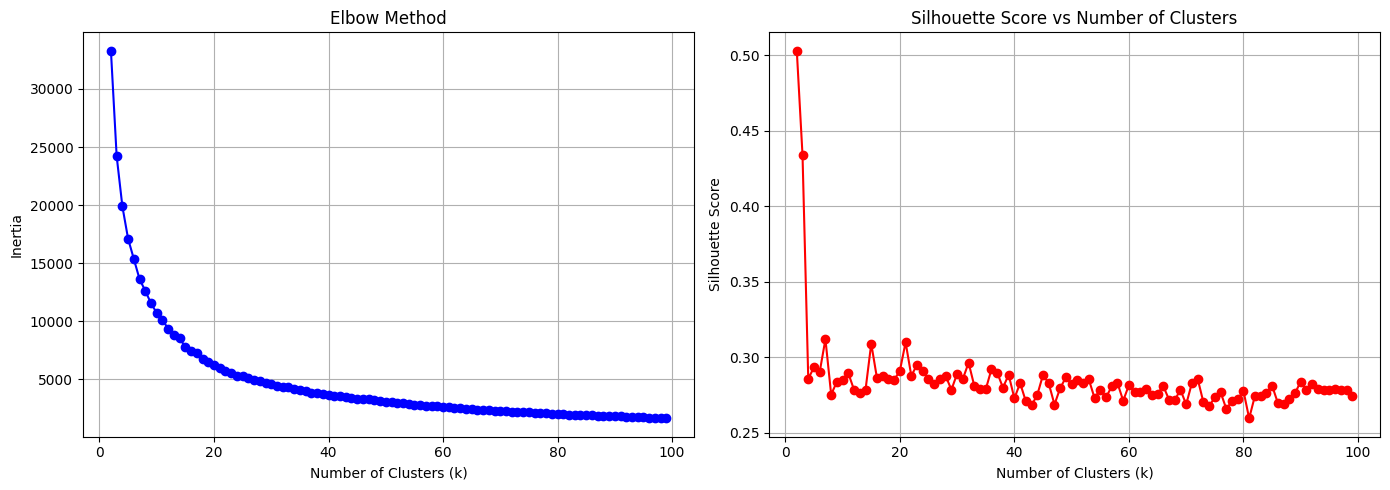

In [9]:
# Elbow method and silhouette scores
inertias = []
silhouette_scores = []
k_range = range(2, 100)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs Number of Clusters')
ax2.grid(True)

plt.tight_layout()

In [10]:
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal k based on silhouette score: {optimal_k}")

Optimal k based on silhouette score: 2


In [20]:
n_clusters = 15

results = {}

# 1. K-Means
print("\n1. K-Means Clustering...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
results['KMeans'] = kmeans.fit_predict(X_scaled)

# 2. Hierarchical Clustering (Agglomerative)
print("2. Hierarchical Clustering...")
hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
results['Hierarchical'] = hierarchical.fit_predict(X_scaled)

# 3. Gaussian Mixture Model
print("3. Gaussian Mixture Model...")
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
results['GMM'] = gmm.fit_predict(X_scaled)

# 4. DBSCAN (density-based)
print("4. DBSCAN...")
dbscan = DBSCAN(eps=3.0, min_samples=5)
results['DBSCAN'] = dbscan.fit_predict(X_scaled)

# ========================================
# Step 5: Evaluate clustering performance
# ========================================

print("\n" + "="*60)
print("Clustering Performance Metrics")
print("="*60)

metrics_df = []

for name, labels in results.items():
    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1) if -1 in labels else 0
    
    # Calculate metrics (skip if only one cluster)
    if n_clusters_found > 1:
        silhouette = silhouette_score(X_scaled, labels)
        davies_bouldin = davies_bouldin_score(X_scaled, labels)
        calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    else:
        silhouette = davies_bouldin = calinski_harabasz = np.nan
    
    metrics_df.append({
        'Algorithm': name,
        'Clusters': n_clusters_found,
        'Noise Points': n_noise,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies_bouldin,
        'Calinski-Harabasz Score': calinski_harabasz
    })
    
    print(f"\n{name}:")
    print(f"  - Clusters found: {n_clusters_found}")
    print(f"  - Noise points: {n_noise}")
    if n_clusters_found > 1:
        print(f"  - Silhouette Score: {silhouette:.4f} (higher is better)")
        print(f"  - Davies-Bouldin Index: {davies_bouldin:.4f} (lower is better)")
        print(f"  - Calinski-Harabasz Score: {calinski_harabasz:.2f} (higher is better)")

metrics_summary = pd.DataFrame(metrics_df)
print("\n" + "="*60)
print(metrics_summary.to_string(index=False))


1. K-Means Clustering...
2. Hierarchical Clustering...
3. Gaussian Mixture Model...
4. DBSCAN...

Clustering Performance Metrics

KMeans:
  - Clusters found: 15
  - Noise points: 0
  - Silhouette Score: 0.3090 (higher is better)
  - Davies-Bouldin Index: 1.0356 (lower is better)
  - Calinski-Harabasz Score: 337.18 (higher is better)

Hierarchical:
  - Clusters found: 15
  - Noise points: 0
  - Silhouette Score: 0.2739 (higher is better)
  - Davies-Bouldin Index: 1.1113 (lower is better)
  - Calinski-Harabasz Score: 309.56 (higher is better)

GMM:
  - Clusters found: 15
  - Noise points: 0
  - Silhouette Score: 0.2726 (higher is better)
  - Davies-Bouldin Index: 1.1758 (lower is better)
  - Calinski-Harabasz Score: 306.92 (higher is better)

DBSCAN:
  - Clusters found: 4
  - Noise points: 97
  - Silhouette Score: 0.1989 (higher is better)
  - Davies-Bouldin Index: 1.2963 (lower is better)
  - Calinski-Harabasz Score: 72.79 (higher is better)

   Algorithm  Clusters  Noise Points  Silho


Creating visualizations...
PCA explained variance: 78.42%


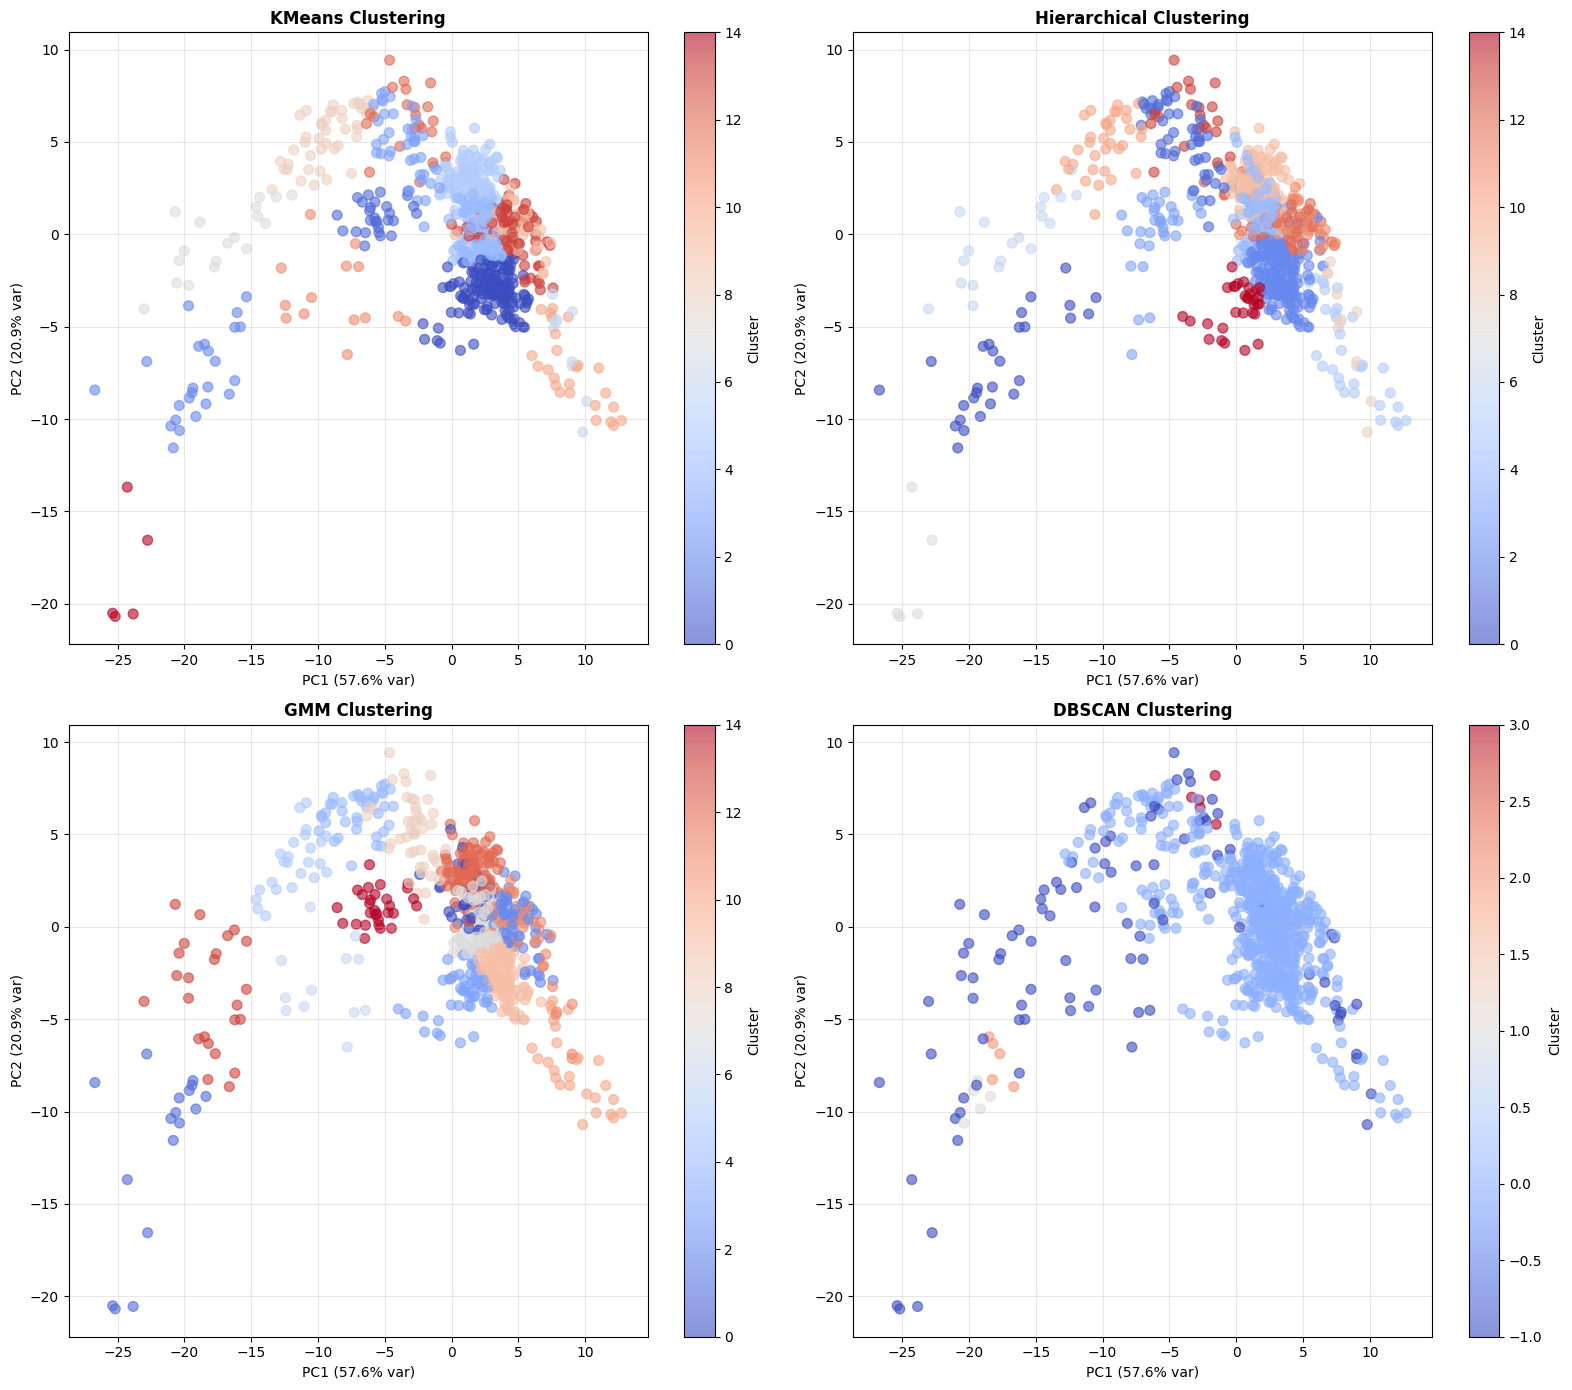

In [21]:
from sklearn.decomposition import PCA

print("\nCreating visualizations...")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# Create subplots for each algorithm
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, (name, labels) in enumerate(results.items()):
    scatter = axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, 
                                cmap='coolwarm', alpha=0.6, s=50)
    axes[idx].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    axes[idx].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
    axes[idx].set_title(f'{name} Clustering', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=axes[idx], label='Cluster')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()

In [22]:
kmeans_district_labels = df[['feature']].copy()
kmeans_district_labels = kmeans_district_labels.drop_duplicates(subset='feature')
kmeans_district_labels['KMeans_Cluster'] = results['KMeans']
kmeans_district_labels

,feature,KMeans_Cluster
0,A & N Islands_Nicobars,6
12,A & N Islands_North And Middle Andaman,6
24,A & N Islands_South Andamans,6
36,Andhra Pradesh_Alluri Sitharama Raju,5
48,Andhra Pradesh_Anakapalli,13
...,...,...
9216,West Bengal_Murshidabad,4
9228,West Bengal_Nadia,4
9240,West Bengal_Paschim Bardhaman,4
9252,West Bengal_Purba Bardhaman,4


In [23]:
# separating feature column into state and district by splitting at underscore
kmeans_district_labels[['State', 'District']] = kmeans_district_labels['feature'].str.split('_', n=1, expand=True)
kmeans_district_labels

,feature,KMeans_Cluster,State,District
0,A & N Islands_Nicobars,6,A & N Islands,Nicobars
12,A & N Islands_North And Middle Andaman,6,A & N Islands,North And Middle Andaman
24,A & N Islands_South Andamans,6,A & N Islands,South Andamans
36,Andhra Pradesh_Alluri Sitharama Raju,5,Andhra Pradesh,Alluri Sitharama Raju
48,Andhra Pradesh_Anakapalli,13,Andhra Pradesh,Anakapalli
...,...,...,...,...
9216,West Bengal_Murshidabad,4,West Bengal,Murshidabad
9228,West Bengal_Nadia,4,West Bengal,Nadia
9240,West Bengal_Paschim Bardhaman,4,West Bengal,Paschim Bardhaman
9252,West Bengal_Purba Bardhaman,4,West Bengal,Purba Bardhaman


In [24]:
kmeans_district_labels.to_csv('kmeans_district_clusters_tp_t2m_slt.csv', index=False)

In [25]:
gmm_district_labels = df[['feature']].copy()
gmm_district_labels = gmm_district_labels.drop_duplicates(subset='feature')
gmm_district_labels['GMM_Cluster'] = results['GMM']

# separating feature column into state and district by splitting at underscore
gmm_district_labels[['State', 'District']] = gmm_district_labels['feature'].str.split('_', n=1, expand=True)

gmm_district_labels.to_csv('gmm_district_clusters_tp_t2m_slt.csv', index=False)

In [26]:
comparison_df = pd.read_csv('new_start/for_comparison.csv')

In [27]:
from sklearn.metrics import adjusted_rand_score

adjusted_rand_score(comparison_df['label'], kmeans_district_labels['KMeans_Cluster'])

0.3330281796146329

In [28]:
adjusted_rand_score(comparison_df['label'], gmm_district_labels['GMM_Cluster'])

0.2854582717193323

In [31]:
h_district_labels = df[['feature']].copy()
h_district_labels = h_district_labels.drop_duplicates(subset='feature')
h_district_labels['H_Cluster'] = results['Hierarchical']

# separating feature column into state and district by splitting at underscore
h_district_labels[['State', 'District']] = h_district_labels['feature'].str.split('_', n=1, expand=True)

h_district_labels.to_csv('h_district_clusters_tp_t2m_slt.csv', index=False)

In [30]:
adjusted_rand_score(comparison_df['label'], h_district_labels['H_Cluster'])

0.2824000630602144